# Лабораторная работа 13 — Ансамбли: стекинг

**Цель работы:** изучить методы стекинга и голосования, построить ансамбли из разнородных моделей, проанализировать вклад каждого базового классификатора.

## Теоретическое введение

### Стекинг (Stacking)

**Стекинг** — метод ансамблирования, при котором предсказания нескольких **разнородных** базовых моделей (base estimators) используются как входные признаки для **мета-модели** (final estimator), которая обучается комбинировать их оптимальным образом.

В отличие от бэггинга и бустинга, стекинг объединяет принципиально разные алгоритмы (деревья, KNN, линейные модели и т.д.), используя сильные стороны каждого.

Для избежания переобучения предсказания базовых моделей формируются через **кросс-валидацию**: каждая базовая модель делает предсказания на части данных, на которой не обучалась.

### Голосование (Voting)

Более простой подход — **VotingClassifier**:
- **Hard voting**: каждая модель голосует за класс, побеждает большинство
- **Soft voting**: усредняются предсказанные вероятности, побеждает класс с максимальной средней вероятностью

Soft voting обычно лучше, так как учитывает уверенность моделей.

## 1. Загрузка и предобработка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.ensemble import (
    StackingClassifier, VotingClassifier,
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

df = pd.read_csv('../datasets/gtzan/features_30_sec.csv')
X = df.drop(columns=['filename', 'label', 'length'])
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'Датасет: {X.shape[0]} сэмплов, {X.shape[1]} признаков, {len(le.classes_)} классов')
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Датасет: 1000 сэмплов, 57 признаков, 10 классов
Train: 800, Test: 200


## 2. Базовые модели

Обучим отдельные модели для сравнения с ансамблями.

In [2]:
base_estimators = [
    ('dt', DecisionTreeClassifier(max_depth=10, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('lr', LogisticRegression(max_iter=2000, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)),
]

base_results = {}
print('=== Базовые модели ===')
for name, model in base_estimators:
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    base_results[name] = acc
    print(f'  {name:4s}: accuracy = {acc:.4f}')

=== Базовые модели ===
  dt  : accuracy = 0.4900
  knn : accuracy = 0.6800
  lr  : accuracy = 0.7100


  rf  : accuracy = 0.6750


  gb  : accuracy = 0.6900


## 3. VotingClassifier (голосование)

Объединим базовые модели голосованием: **hard** (большинство) и **soft** (средняя вероятность).

In [3]:
estimators_for_voting = [
    ('dt', DecisionTreeClassifier(max_depth=10, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('lr', LogisticRegression(max_iter=2000, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)),
]

voting_hard = VotingClassifier(estimators=estimators_for_voting, voting='hard', n_jobs=-1)
voting_hard.fit(X_train, y_train)
acc_hard = accuracy_score(y_test, voting_hard.predict(X_test))

voting_soft = VotingClassifier(estimators=estimators_for_voting, voting='soft', n_jobs=-1)
voting_soft.fit(X_train, y_train)
acc_soft = accuracy_score(y_test, voting_soft.predict(X_test))

print(f'Hard Voting: accuracy = {acc_hard:.4f}')
print(f'Soft Voting: accuracy = {acc_soft:.4f}')

Hard Voting: accuracy = 0.7250
Soft Voting: accuracy = 0.7450


## 4. StackingClassifier

Стекинг использует мета-модель (LogisticRegression), которая обучается комбинировать предсказания базовых классификаторов. Предсказания базовых моделей формируются через кросс-валидацию.

In [4]:
estimators_for_stacking = [
    ('dt', DecisionTreeClassifier(max_depth=10, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('lr', LogisticRegression(max_iter=2000, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)),
]

stacking_clf = StackingClassifier(
    estimators=estimators_for_stacking,
    final_estimator=LogisticRegression(max_iter=2000, random_state=42),
    cv=5, n_jobs=-1
)
stacking_clf.fit(X_train, y_train)

y_pred_stack = stacking_clf.predict(X_test)
y_proba_stack = stacking_clf.predict_proba(X_test)
acc_stack = accuracy_score(y_test, y_pred_stack)

print(f'Stacking: accuracy = {acc_stack:.4f}')
print()
print(classification_report(y_test, y_pred_stack, target_names=le.classes_))

Stacking: accuracy = 0.7650

              precision    recall  f1-score   support

       blues       0.84      0.80      0.82        20
   classical       0.95      0.90      0.92        20
     country       0.77      0.85      0.81        20
       disco       0.67      0.50      0.57        20
      hiphop       0.64      0.90      0.75        20
        jazz       0.77      0.85      0.81        20
       metal       1.00      0.75      0.86        20
         pop       0.84      0.80      0.82        20
      reggae       0.71      0.60      0.65        20
        rock       0.58      0.70      0.64        20

    accuracy                           0.77       200
   macro avg       0.78      0.76      0.76       200
weighted avg       0.78      0.77      0.76       200



### 4.1 Сравнение всех моделей

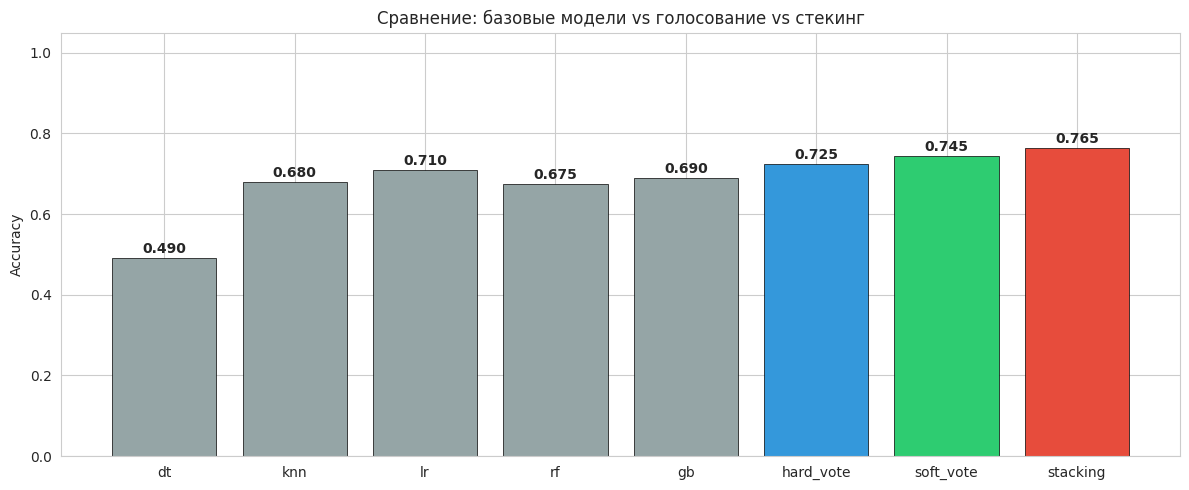

In [5]:
all_results = {**base_results, 'hard_vote': acc_hard, 'soft_vote': acc_soft, 'stacking': acc_stack}

fig, ax = plt.subplots(figsize=(12, 5))
names = list(all_results.keys())
accs = list(all_results.values())
colors = ['#95a5a6'] * len(base_results) + ['#3498db', '#2ecc71', '#e74c3c']

bars = ax.bar(names, accs, color=colors, edgecolor='black', linewidth=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_ylabel('Accuracy')
ax.set_title('Сравнение: базовые модели vs голосование vs стекинг')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 5. Confusion matrix и ROC — стекинг

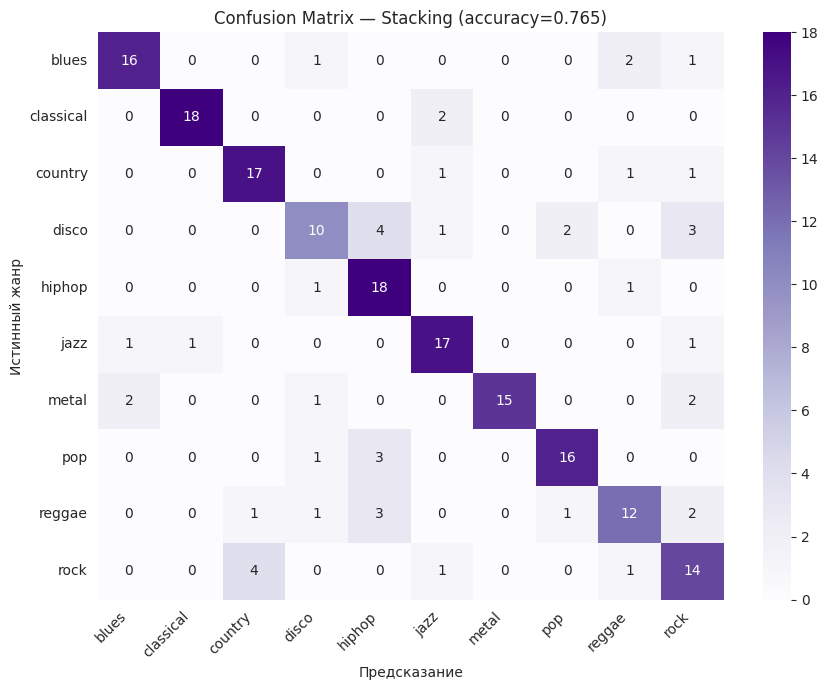

In [6]:
cm = confusion_matrix(y_test, y_pred_stack)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_xlabel('Предсказание')
ax.set_ylabel('Истинный жанр')
ax.set_title(f'Confusion Matrix — Stacking (accuracy={acc_stack:.3f})')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

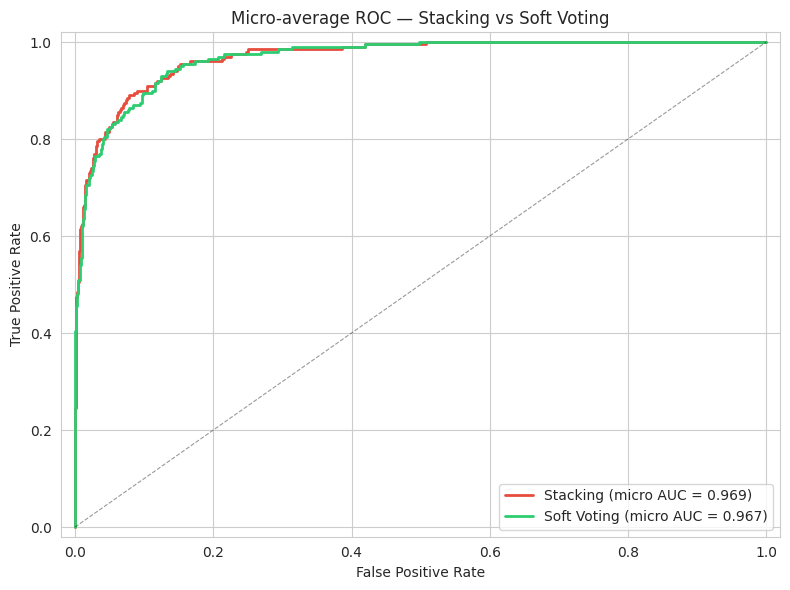

In [7]:
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# ROC для stacking и soft voting
fig, ax = plt.subplots(figsize=(8, 6))
ensembles = [
    ('Stacking', stacking_clf, '#e74c3c'),
    ('Soft Voting', voting_soft, '#2ecc71'),
]

for name, model, color in ensembles:
    y_proba = model.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (micro AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Micro-average ROC — Stacking vs Soft Voting')
ax.legend(loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

## 6. Анализ коэффициентов мета-модели

Мета-модель (LogisticRegression) комбинирует предсказания базовых классификаторов. Её коэффициенты показывают, **какой базовый классификатор вносит наибольший вклад** в итоговое предсказание.

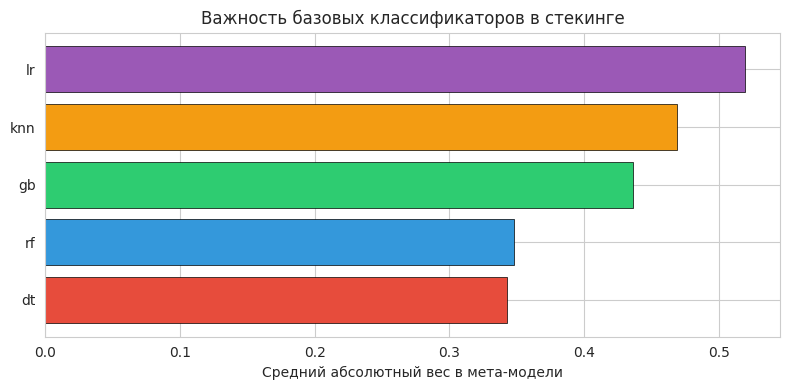


Веса базовых классификаторов в мета-модели:
  dt  : 0.3431
  knn : 0.4693
  lr  : 0.5195
  rf  : 0.3481
  gb  : 0.4364

Наиболее важный классификатор: lr


In [8]:
meta_model = stacking_clf.final_estimator_
coef = meta_model.coef_  # shape: (n_classes, n_base_estimators * n_classes)

# Каждый базовый классификатор выдаёт n_classes вероятностей
est_names = [name for name, _ in estimators_for_stacking]
n_est = len(est_names)

# Средний абсолютный вес для каждого базового классификатора
avg_weights = []
for i in range(n_est):
    start = i * n_classes
    end = start + n_classes
    avg_w = np.abs(coef[:, start:end]).mean()
    avg_weights.append(avg_w)

weight_df = pd.DataFrame({'Классификатор': est_names, 'Средний |вес|': avg_weights})
weight_df = weight_df.sort_values('Средний |вес|', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(weight_df['Классификатор'], weight_df['Средний |вес|'],
        color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6'],
        edgecolor='black', linewidth=0.5)
ax.set_xlabel('Средний абсолютный вес в мета-модели')
ax.set_title('Важность базовых классификаторов в стекинге')
plt.tight_layout()
plt.show()

print('\nВеса базовых классификаторов в мета-модели:')
for name, w in zip(est_names, avg_weights):
    print(f'  {name:4s}: {w:.4f}')
print(f'\nНаиболее важный классификатор: {est_names[np.argmax(avg_weights)]}')

## 7. Кросс-валидация

Сравним ансамблевые методы через 5-fold кросс-валидацию.

Soft Voting : 0.7500 ± 0.0332


Stacking    : 0.7370 ± 0.0191


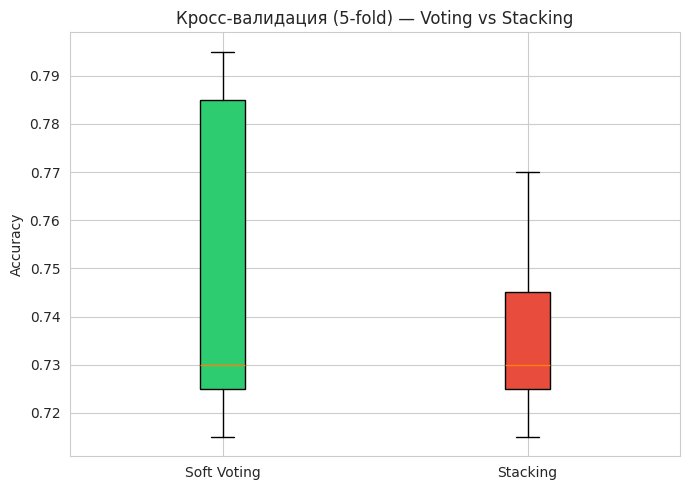

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Soft Voting': VotingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(max_depth=10, random_state=42)),
            ('knn', KNeighborsClassifier(n_neighbors=5)),
            ('lr', LogisticRegression(max_iter=2000, random_state=42)),
            ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)),
            ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)),
        ], voting='soft', n_jobs=-1),
    'Stacking': StackingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(max_depth=10, random_state=42)),
            ('knn', KNeighborsClassifier(n_neighbors=5)),
            ('lr', LogisticRegression(max_iter=2000, random_state=42)),
            ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)),
            ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)),
        ],
        final_estimator=LogisticRegression(max_iter=2000, random_state=42),
        cv=5, n_jobs=-1),
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_scaled, y_encoded, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot([cv_results[n] for n in cv_results],
                labels=list(cv_results.keys()), patch_artist=True)
colors_box = ['#2ecc71', '#e74c3c']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
ax.set_ylabel('Accuracy')
ax.set_title('Кросс-валидация (5-fold) — Voting vs Stacking')
plt.tight_layout()
plt.show()

## Выводы

1. **Стекинг** объединяет разнородные модели через мета-классификатор и может превосходить как отдельные базовые модели, так и простое голосование.

2. **Soft Voting** — более простой подход, который усредняет вероятности. Он эффективен, когда базовые модели имеют сопоставимое качество.

3. **Анализ коэффициентов** мета-модели показал, что наибольший вклад вносят модели, которые сильнее всего отличаются по своей природе от остальных (обычно ансамблевые модели — RF, GB).

4. Стекинг наиболее эффективен, когда базовые модели **разнообразны** по природе (деревья + линейные + метрические) и ошибаются на разных примерах.

5. Стекинг вычислительно затратнее бэггинга и бустинга, но позволяет максимально использовать сильные стороны каждого метода.

6. На датасете GTZAN стекинг из 5 моделей показывает одно из лучших качеств среди всех рассмотренных в курсе подходов.